# Heart Disease Classifier — Model Comparison
Loads all runs from the `classification-comparison` MLflow experiment and compares all four models across key metrics.

In [6]:
import os
import tempfile
import warnings
warnings.filterwarnings('ignore')

import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.ticker as mticker
from mlflow.tracking import MlflowClient

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

db_path = 'mlflow.db'
if not os.path.exists(db_path):
    db_path = '../mlflow.db'
mlflow.set_tracking_uri(f'sqlite:///{os.path.abspath(db_path)}')
client = MlflowClient()
print('Tracking URI:', mlflow.get_tracking_uri())

Tracking URI: sqlite:///e:\Job projects\BMO\classification-mlflow\mlflow.db


## Load Runs from MLflow

In [7]:
experiment = client.get_experiment_by_name('classification-comparison')
if experiment is None:
    raise RuntimeError("Experiment 'classification-comparison' not found. Run main.py first.")

raw = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="attributes.status = 'FINISHED'",
)

METRIC_COLS = ['metrics.accuracy', 'metrics.precision', 'metrics.recall', 'metrics.f1', 'metrics.roc_auc']

runs_df = (
    raw[['run_id', 'start_time', 'tags.mlflow.runName'] + METRIC_COLS]
    .rename(columns={
        'tags.mlflow.runName': 'model',
        **{c: c.split('.')[1] for c in METRIC_COLS},
    })
    .dropna(subset=['model'])                               # drop unnamed/orphan runs
    .sort_values('start_time', ascending=False)
    .drop_duplicates(subset='model', keep='first')          # keep most recent run per model
    .sort_values('f1', ascending=False)
    .drop(columns='start_time')
    .reset_index(drop=True)
)

assert len(runs_df) == 4, f"Expected 4 models, got {len(runs_df)}: {runs_df['model'].tolist()}"
print(f"Loaded {len(runs_df)} models (most recent finished run each)")
runs_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

Loaded 4 models (most recent finished run each)


,model,accuracy,precision,recall,f1,roc_auc
0,xgboost,0.866667,0.884615,0.821429,0.851852,0.891741
1,random_forest,0.850000,0.880000,0.785714,0.830189,0.940848
2,logistic_regression,0.833333,0.846154,0.785714,0.814815,0.948661
3,random_forest_tuned,0.833333,0.909091,0.714286,0.800000,0.947545


## Metrics Comparison Table

In [8]:
table = (
    runs_df
    .drop_duplicates(subset='model', keep='first')
    .set_index('model')
    [['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
)

table.style \
    .format('{:.4f}') \
    .set_caption('Model Comparison — all metrics (higher is better)') \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding-bottom', '10px')]},
        {'selector': 'thead th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px'), ('text-align', 'center'), ('padding', '8px 14px')]},
        {'selector': 'tbody th', 'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold'), ('padding', '7px 14px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '7px 14px'), ('border-bottom', '1px solid #ddd')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#eaf4fb')]},
    ])

,accuracy,precision,recall,f1,roc_auc
model,,,,,
xgboost,0.8667,0.8846,0.8214,0.8519,0.8917
random_forest,0.8500,0.8800,0.7857,0.8302,0.9408
logistic_regression,0.8333,0.8462,0.7857,0.8148,0.9487
random_forest_tuned,0.8333,0.9091,0.7143,0.8000,0.9475


## Grouped Bar Chart — Accuracy, F1, ROC-AUC

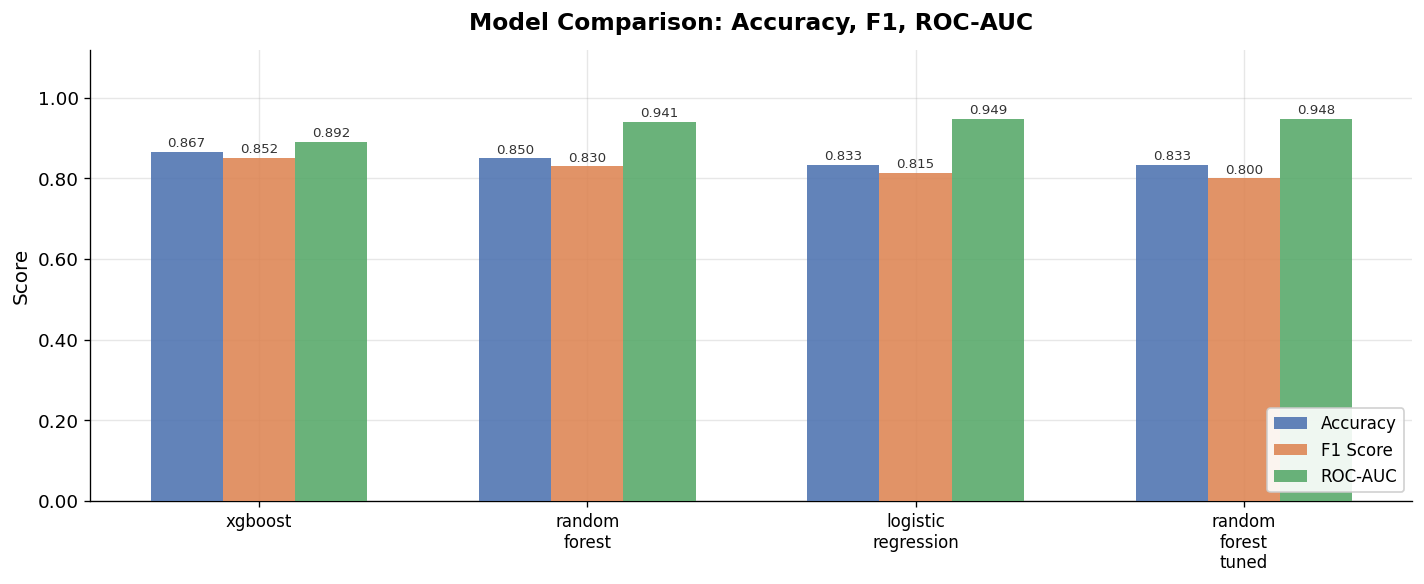

In [9]:
METRICS    = ['accuracy', 'f1', 'roc_auc']
LABELS     = ['Accuracy', 'F1 Score', 'ROC-AUC']
COLORS     = ['#4C72B0', '#DD8452', '#55A868']
models     = runs_df['model'].tolist()
n_models   = len(models)
n_metrics  = len(METRICS)

x          = np.arange(n_models)
bar_width  = 0.22
offsets    = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_width

fig, ax = plt.subplots(figsize=(12, 5))

for offset, metric, label, color in zip(offsets, METRICS, LABELS, COLORS):
    values = runs_df[metric].values
    bars = ax.bar(x + offset, values, width=bar_width, label=label, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8, color='#333333'
        )

ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', '\n') for m in models], fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Accuracy, F1, ROC-AUC', fontsize=14, fontweight='bold', pad=12)
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend(framealpha=0.9, fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Confusion Matrices

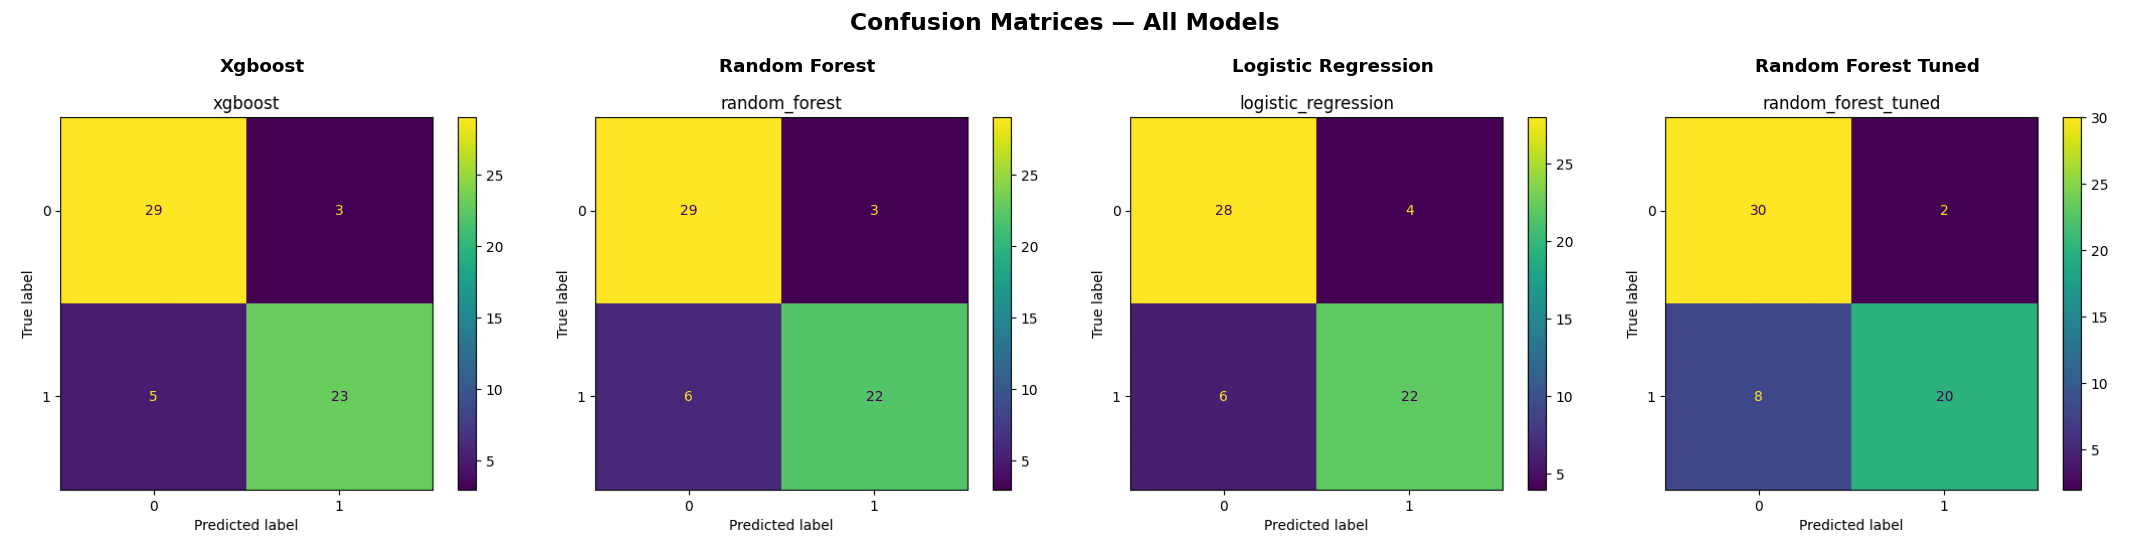

In [10]:
n = len(runs_df)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, runs_df.iterrows()):
    with tempfile.TemporaryDirectory() as tmpdir:
        local_path = client.download_artifacts(row['run_id'], 'confusion_matrix.png', tmpdir)
        img = mpimg.imread(local_path)
    ax.imshow(img)
    ax.set_title(row['model'].replace('_', ' ').title(), fontsize=11, fontweight='bold', pad=8)
    ax.axis('off')

fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()